# UnlimitedOCR demo

This notebook uses the high-level `UnlimitedOCR` API. No model, library, or Metal resource paths need to be configured here; the package resolves local artifacts or downloads the model into its cache on first use.


In [1]:
from pathlib import Path
from IPython.display import display
from PIL import Image
from unlimitedocr_c import UnlimitedOCR

IMAGE_PATH = Path('/Users/mascit/Documents/Screenshot 2026-06-26 at 17.35.54.png')
#IMAGE_PATH = Path('../docs/test.png')

ocr = UnlimitedOCR()
print('model:', ocr.model_path)
print('image:', IMAGE_PATH)


model: /Users/mascit/projects/unlimitedocr.c/dist/unlimitedocr-fp16.uocr
image: /Users/mascit/Documents/Screenshot 2026-06-26 at 17.35.54.png


In [2]:
IMAGE_PATH = Path('/Users/mascit/Documents/Screenshot 2026-06-26 at 17.35.54.png')

## Input image


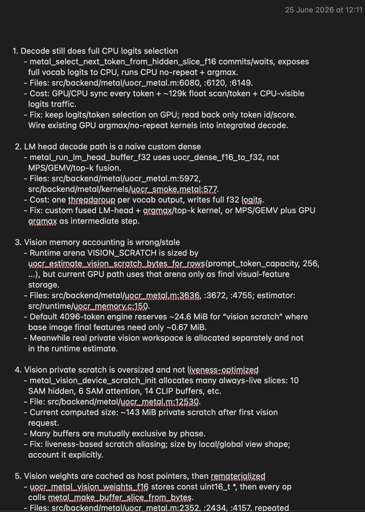

In [3]:
image = Image.open(IMAGE_PATH)
image.thumbnail((512, 512))
display(image)

## Run OCR


In [4]:
text = ocr.generate(IMAGE_PATH, profile='base')
print(text)

<|det|>header [775, 10, 999, 28]<|/det|>25 June 2026 at 12:11
<|det|>text [33, 89, 490, 109]<|/det|>1. Decode still does full CPU logits selection
<|det|>text [62, 110, 851, 150]<|/det|>- metal_select_next_token_from_hidden_slice_f16 commits/waits, exposes full vocab logits to CPU, runs CPU no-repeat + argmax.
<|det|>text [62, 152, 692, 171]<|/det|>- Files: src/backend/metal/uocr_metal.m:6080, :6120, :6149.
<|det|>text [62, 172, 835, 212]<|/det|>- Cost: GPU/CPU sync every token + ~129k float scan/token + CPU-visible logits traffic.
<|det|>text [62, 214, 812, 255]<|/det|>- Fix: keep logits/token selection on GPU; read back only token id/score. Wire existing GPU argmax/no-repeat kernels into integrated decode.
<|det|>text [35, 276, 554, 294]<|/det|>2. LM head decode path is a naive custom dense
<|det|>text [62, 296, 763, 336]<|/det|>- metal_run_lm_head_buffer_f32 uses uocr_dense_f16_to_f32, not MPS/GEMV/top-k fusion.
<|det|>text [62, 338, 598, 379]<|/det|>- Files: src/backend/metal/uocr_